Tea Leaf Disease Model Training

In [1]:
import os

# Define the output directory
output_dir = '/content/Tea_Leaf_Diseases'

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Unzip the file to the specified directory
!unzip '/content/Tea Leaf Diseases.zip' -d {output_dir}

Streaming output truncated to the last 5000 lines.
 extracting: /content/Tea_Leaf_Diseases/train/labels/20211225_232815_jpg.rf.c495def9c4d45ce285b182c5fc37fb23.txt  
 extracting: /content/Tea_Leaf_Diseases/train/labels/20211225_232840_jpg.rf.73c20b00f26f980965c345c8b31407a2.txt  
 extracting: /content/Tea_Leaf_Diseases/train/labels/20211225_232840_jpg.rf.92136a5672f065e971eb66ea4ecc9770.txt  
 extracting: /content/Tea_Leaf_Diseases/train/labels/20211225_232857_jpg.rf.0066880c7a6cc7c4282ff14f8f43c07b.txt  
 extracting: /content/Tea_Leaf_Diseases/train/labels/20211225_232938_jpg.rf.0b45eb17fb20a20d5131f72ac0c95808.txt  
 extracting: /content/Tea_Leaf_Diseases/train/labels/20211225_233401_jpg.rf.029efd0cc3bc591feafb4f3604c5bbb4.txt  
 extracting: /content/Tea_Leaf_Diseases/train/labels/20211225_233401_jpg.rf.fb14e35ba5805b12ee2130ca7159c2bc.txt  
 extracting: /content/Tea_Leaf_Diseases/train/labels/20211225_233427_jpg.rf.a9f3173f601fd2d90af227ffa8eb6b61.txt  
 extracting: /content/Tea_Lea

In [4]:
output_dir = '/content/Tea_Leaf_Diseases'
!ls -F {output_dir}

data.yaml  README.dataset.txt  README.roboflow.txt  test/  train/  valid/


In [5]:
output_dir = '/content/Tea_Leaf_Diseases'
!cat {output_dir}/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 6
names: ['Algal Leaf Spot', 'Brown Blight', 'Gray Blight', 'Healthy', 'Helopeltis', 'Red Leaf Spot']

roboflow:
  workspace: roboflow-rrghp
  project: tea-leaf-diseases-heo0k
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/roboflow-rrghp/tea-leaf-diseases-heo0k/dataset/1

## Load and Preprocess Data

Load the image datasets for training, validation, and testing from the respective directories. Apply essential preprocessing steps such as resizing, normalization, and data augmentation suitable for a ResNet50 model using `torchvision.transforms`.


**Reasoning**:
The subtask requires loading and preprocessing image datasets. I will import the necessary PyTorch and torchvision libraries, define data transformations for training, validation, and testing, and then create ImageFolder datasets for each split.



In [8]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import os
import shutil
import yaml

# Define the base directory for the extracted dataset
output_dir = '/content/Tea_Leaf_Diseases'
reorganized_output_dir = '/content/Tea_Leaf_Diseases_reorganized'

# Create the reorganized base directory
os.makedirs(reorganized_output_dir, exist_ok=True)

# --- Step 1: Reorganize the dataset into ImageFolder-compatible format ---

# Load class names from data.yaml
data_yaml_path = f'{output_dir}/data.yaml'
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)
class_names = data_config['names']

# Iterate through train, valid, test splits
for split in ['train', 'valid', 'test']:
    source_images_dir = os.path.join(output_dir, split, 'images')
    source_labels_dir = os.path.join(output_dir, split, 'labels')
    target_split_dir = os.path.join(reorganized_output_dir, split)

    # Create target split directory if it doesn't exist
    os.makedirs(target_split_dir, exist_ok=True)

    # Create class subdirectories within the target split directory
    for class_name in class_names:
        os.makedirs(os.path.join(target_split_dir, class_name), exist_ok=True)

    # Reorganize images
    if os.path.exists(source_images_dir):
        print(f"Reorganizing {split} split from {source_images_dir}...")
        for image_filename in os.listdir(source_images_dir):
            if image_filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                image_base_name = os.path.splitext(image_filename)[0]
                label_filename = f"{image_base_name}.txt"
                label_filepath = os.path.join(source_labels_dir, label_filename)

                if os.path.exists(label_filepath):
                    with open(label_filepath, 'r') as f:
                        # Assuming one line, first element is class ID for classification
                        first_line = f.readline().strip()
                        if first_line:
                            class_id = int(first_line.split(' ')[0])
                            if 0 <= class_id < len(class_names):
                                class_name = class_names[class_id]
                                source_image_path = os.path.join(source_images_dir, image_filename)
                                target_image_path = os.path.join(target_split_dir, class_name, image_filename)
                                # Using shutil.copy2 to preserve metadata, can use shutil.move if original files are not needed
                                shutil.copy2(source_image_path, target_image_path)
                            else:
                                print(f"Warning: Class ID {class_id} out of bounds for image {image_filename} in {split} split.")
                        else:
                            print(f"Warning: Empty label file for image {image_filename} in {split} split.")
                else:
                    print(f"Warning: No label file found for image {image_filename} in {split} split.")
        print(f"Finished reorganizing {split} split.")
    else:
        print(f"Source images directory not found for {split} split: {source_images_dir}")


# --- Step 2: Define transformations and create ImageFolder datasets with the reorganized data ---

# Adjust paths to point to the new reorganized directories
train_dir = f'{reorganized_output_dir}/train'
val_dir = f'{reorganized_output_dir}/valid'
test_dir = f'{reorganized_output_dir}/test'

# Define transformations for the training set (with data augmentation)
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Define transformations for the validation and testing sets (without data augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create ImageFolder datasets
train_dataset = ImageFolder(train_dir, train_transforms)
val_dataset = ImageFolder(val_dir, val_test_transforms)
test_dataset = ImageFolder(test_dir, val_test_transforms)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")
print(f"Class names (from ImageFolder): {train_dataset.classes}")
print(f"Class names (from data.yaml): {class_names}")


Reorganizing train split from /content/Tea_Leaf_Diseases/train/images...
Finished reorganizing train split.
Reorganizing valid split from /content/Tea_Leaf_Diseases/valid/images...
Finished reorganizing valid split.
Reorganizing test split from /content/Tea_Leaf_Diseases/test/images...
Finished reorganizing test split.
Number of training samples: 4259
Number of validation samples: 421
Number of testing samples: 421
Class names (from ImageFolder): ['Algal Leaf Spot', 'Brown Blight', 'Gray Blight', 'Healthy', 'Helopeltis', 'Red Leaf Spot']
Class names (from data.yaml): ['Algal Leaf Spot', 'Brown Blight', 'Gray Blight', 'Healthy', 'Helopeltis', 'Red Leaf Spot']


## Create DataLoaders

Generate PyTorch `DataLoader` objects for the training, validation, and test datasets. These will efficiently handle batching and shuffling of the data during model training and evaluation.


**Reasoning**:
To efficiently handle batching and shuffling of the data for model training and evaluation, I will create `DataLoader` objects for the training, validation, and test datasets, using a defined `batch_size` and appropriate `shuffle` settings.



In [9]:
from torch.utils.data import DataLoader

# Define batch size
batch_size = 32

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training DataLoader created with batch size {batch_size} and shuffle=True. Number of batches: {len(train_loader)}")
print(f"Validation DataLoader created with batch size {batch_size} and shuffle=False. Number of batches: {len(val_loader)}")
print(f"Test DataLoader created with batch size {batch_size} and shuffle=False. Number of batches: {len(test_loader)}")

Training DataLoader created with batch size 32 and shuffle=True. Number of batches: 134
Validation DataLoader created with batch size 32 and shuffle=False. Number of batches: 14
Test DataLoader created with batch size 32 and shuffle=False. Number of batches: 14


## Load Pre-trained ResNet50 Model

Initialize a ResNet50 model pre-trained on ImageNet, which will serve as the base for transfer learning. Freeze the weights of the convolutional layers to retain learned features.


**Reasoning**:
To initialize a pre-trained ResNet50 model and freeze its convolutional layers, I need to import the necessary PyTorch modules and then load the ResNet50 model with pre-trained weights. Following this, I will iterate through the model's parameters to set `requires_grad` to `False` for all layers, effectively freezing them.



In [10]:
import torch
import torch.nn as nn
import torchvision.models as models

# 1. Load a pre-trained ResNet50 model
# Set `weights=ResNet50_Weights.IMAGENET1K_V1` to load the best available weights (ImageNet-1K V1)
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# 2. Freeze the weights of all layers
for param in resnet50.parameters():
    param.requires_grad = False

print("Pre-trained ResNet50 model loaded and all convolutional layers frozen.")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 162MB/s]


Pre-trained ResNet50 model loaded and all convolutional layers frozen.


**Reasoning**:
The previous step successfully loaded and froze the pre-trained ResNet50 model. The next logical step is to adapt the model for our specific classification task by replacing the original classifier head with a new one that matches the number of classes in our dataset.



In [11]:
import torch
import torch.nn as nn
import torchvision.models as models

# 1. Load a pre-trained ResNet50 model
# Set `weights=ResNet50_Weights.IMAGENET1K_V1` to load the best available weights (ImageNet-1K V1)
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# 2. Freeze the weights of all layers
for param in resnet50.parameters():
    param.requires_grad = False

# 3. Replace the classifier head
# Get the number of input features for the last layer
num_ftrs = resnet50.fc.in_features
# Replace the fully connected layer with a new one for our number of classes
# The number of classes can be obtained from the `data_config` dictionary loaded previously.
num_classes = len(data_config['names'])
resnet50.fc = nn.Linear(num_ftrs, num_classes)

# Move the model to the appropriate device (GPU if available, else CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
resnet50 = resnet50.to(device)

print(f"Pre-trained ResNet50 model loaded and all convolutional layers frozen.")
print(f"Classifier head replaced with a new layer for {num_classes} classes.")
print(f"Model moved to device: {device}")

Pre-trained ResNet50 model loaded and all convolutional layers frozen.
Classifier head replaced with a new layer for 6 classes.
Model moved to device: cuda:0


**Reasoning**:
With the model architecture defined, the next critical step is to set up the training components. I will define the loss function, which quantifies the error between predicted and actual values, and the optimizer, which adjusts model weights to minimize this error. Given this is a multi-class classification problem, CrossEntropyLoss is appropriate, and Adam is a robust choice for an optimizer.



In [12]:
import torch.optim as optim

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet50.fc.parameters(), lr=0.001)

print("Loss function (CrossEntropyLoss) and Optimizer (Adam) defined.")
print(f"Only the classifier head's parameters are being optimized: {len(list(optimizer.param_groups[0]['params']))}")

Loss function (CrossEntropyLoss) and Optimizer (Adam) defined.
Only the classifier head's parameters are being optimized: 2


**Reasoning**:
With the model, loss function, and optimizer defined, the next crucial step is to implement the training and evaluation loops. I will define a function to train the model for one epoch, including forward pass, loss calculation, backward pass, and optimizer step. Additionally, I will define a function to evaluate the model on the validation set after each epoch, to monitor performance and prevent overfitting.



In [13]:
import time
import copy

# Function to train the model for one epoch
def train_model(model, criterion, optimizer, dataloader, device):
    model.train()  # Set model to training mode
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)
    return epoch_loss, epoch_acc

# Function to evaluate the model
def evaluate_model(model, criterion, dataloader, device):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    running_corrects = 0

    with torch.no_grad():  # Disable gradient calculations during evaluation
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)
    return epoch_loss, epoch_acc

print("Training and evaluation functions defined.")


Training and evaluation functions defined.


**Reasoning**:
Now that the training and evaluation functions are defined, I will create a full training loop to iterate over multiple epochs, track the model's performance on both training and validation sets, and save the best performing model based on validation accuracy.



In [14]:
num_epochs = 10 # You can adjust this number

best_model_wts = copy.deepcopy(resnet50.state_dict())
best_acc = 0.0

print("Starting model training...")

for epoch in range(num_epochs):
    print(f'Epoch {epoch}/{num_epochs - 1}')
    print('-' * 10)

    # Train phase
    train_loss, train_acc = train_model(resnet50, criterion, optimizer, train_loader, device)
    print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}')

    # Validation phase
    val_loss, val_acc = evaluate_model(resnet50, criterion, val_loader, device)
    print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    # Deep copy the model if it has the best validation accuracy
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(resnet50.state_dict())
        print(f'New best model found with validation accuracy: {best_acc:.4f}')

print('\nTraining complete')
print(f'Best val Acc: {best_acc:.4f}')

# Load best model weights
resnet50.load_state_dict(best_model_wts)
print("Best model weights loaded into the model.")

Starting model training...
Epoch 0/9
----------
Train Loss: 0.9323 Acc: 0.6945
Val Loss: 0.3894 Acc: 0.9192
New best model found with validation accuracy: 0.9192
Epoch 1/9
----------
Train Loss: 0.5403 Acc: 0.8251
Val Loss: 0.2861 Acc: 0.9240
New best model found with validation accuracy: 0.9240
Epoch 2/9
----------
Train Loss: 0.4467 Acc: 0.8493
Val Loss: 0.2270 Acc: 0.9335
New best model found with validation accuracy: 0.9335
Epoch 3/9
----------
Train Loss: 0.4368 Acc: 0.8455
Val Loss: 0.2095 Acc: 0.9382
New best model found with validation accuracy: 0.9382
Epoch 4/9
----------
Train Loss: 0.3975 Acc: 0.8683
Val Loss: 0.1744 Acc: 0.9549
New best model found with validation accuracy: 0.9549
Epoch 5/9
----------
Train Loss: 0.3672 Acc: 0.8781
Val Loss: 0.1617 Acc: 0.9359
Epoch 6/9
----------
Train Loss: 0.3529 Acc: 0.8765
Val Loss: 0.1717 Acc: 0.9430
Epoch 7/9
----------
Train Loss: 0.3668 Acc: 0.8779
Val Loss: 0.1719 Acc: 0.9454
Epoch 8/9
----------
Train Loss: 0.3617 Acc: 0.8760
Val

## Evaluate Model on Test Set

### Subtask:
Evaluate the trained model on the test dataset to assess its final performance and generalization ability.

**Reasoning**:
Now that the training is complete and the best model weights have been loaded, I will use the `evaluate_model` function on the `test_loader` to assess the model's final performance on the unseen test dataset.



In [15]:
print("Evaluating model on the test set...")
test_loss, test_acc = evaluate_model(resnet50, criterion, test_loader, device)
print(f'Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}')

Evaluating model on the test set...
Test Loss: 0.2335 Acc: 0.9287


## Evaluate Model Performance

### Subtask:
Evaluate the trained model's performance on the unseen test dataset. Calculate and report key metrics such as accuracy, precision, recall, and F1-score to assess its effectiveness in detecting tea leaf diseases.


**Reasoning**:
To calculate and report precision, recall, and F1-score for each class, I need to collect all true and predicted labels from the test set. I will iterate through the test_loader, make predictions, and then use `sklearn.metrics.classification_report` to generate the detailed metrics.



In [16]:
from sklearn.metrics import classification_report
import numpy as np

# Set the model to evaluation mode
resnet50.eval()

# Initialize lists to store true and predicted labels
all_preds = []
all_labels = []

print("Collecting predictions for classification report...")

# Iterate through the test_loader
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = resnet50(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
                 precision    recall  f1-score   support

Algal Leaf Spot       0.97      0.90      0.94        42
   Brown Blight       0.83      0.85      0.84        41
    Gray Blight       0.82      0.85      0.83        47
        Healthy       0.95      0.99      0.97       192
     Helopeltis       0.98      0.96      0.97        49
  Red Leaf Spot       0.98      0.82      0.89        50

       accuracy                           0.93       421
      macro avg       0.92      0.90      0.91       421
   weighted avg       0.93      0.93      0.93       421



## Final Task

### Subtask:
Provide a summary of the transfer learning model training process, including the achieved performance metrics and any insights gained.


## Summary:

### Data Analysis Key Findings

*   The dataset contains 6 classes: 'Algal Leaf Spot', 'Brown Blight', 'Gray Blight', 'Healthy', 'Helopeltis', and 'Red Leaf Spot'.
*   The raw dataset was reorganized from an object detection format (YOLO style with separate image and label folders) into an `ImageFolder`-compatible structure, with images sorted into class-specific subdirectories.
*   Data preprocessing included resizing, random horizontal flips for training, center cropping for validation/testing, conversion to tensors, and normalization using ImageNet means and standard deviations.
*   The training dataset consists of 4259 samples, the validation dataset has 421 samples, and the test dataset also has 421 samples.
*   PyTorch `DataLoader` objects were created for training (shuffled, batch size 32, 134 batches), validation (not shuffled, batch size 32, 14 batches), and testing (not shuffled, batch size 32, 14 batches).
*   A pre-trained ResNet50 model was loaded with ImageNet weights, and its convolutional layers were frozen to preserve learned features. The final classification head was replaced with a new layer suitable for 6 output classes.
*   The model was trained for 10 epochs using `CrossEntropyLoss` and the `Adam` optimizer, optimizing only the parameters of the new classification head.
*   During training, the model achieved a best validation accuracy of **95.49\%**.
*   On the unseen test set, the model achieved an overall accuracy of **92.87\%** with a test loss of 0.2335.
*   Detailed performance metrics on the test set include:
    *   **Overall Accuracy:** 93\%
    *   **Macro Average:** Precision: 0.92, Recall: 0.90, F1-score: 0.91
    *   **Weighted Average:** Precision: 0.93, Recall: 0.93, F1-score: 0.93
    *   **Class-wise F1-scores:**
        *   Algal Leaf Spot: 0.94
        *   Brown Blight: 0.84
        *   Gray Blight: 0.83
        *   Healthy: 0.97
        *   Helopeltis: 0.97
        *   Red Leaf Spot: 0.89

### Insights or Next Steps

*   The transfer learning approach with ResNet50 provides strong performance for tea leaf disease classification, achieving over 90\% accuracy. Classes like "Healthy" and "Helopeltis" are particularly well-identified.
*   Further improvements could be explored by unfreezing some of the later convolutional layers of ResNet50 and fine-tuning them with a smaller learning rate, or by implementing more advanced data augmentation techniques to potentially boost performance for classes like "Brown Blight" and "Gray Blight" which have slightly lower F1-scores.


## Summary:

### Data Analysis Key Findings

*   The dataset contains 6 classes: 'Algal Leaf Spot', 'Brown Blight', 'Gray Blight', 'Healthy', 'Helopeltis', and 'Red Leaf Spot'.
*   The raw dataset was reorganized from an object detection format (YOLO style with separate image and label folders) into an `ImageFolder`-compatible structure, with images sorted into class-specific subdirectories.
*   Data preprocessing included resizing, random horizontal flips for training, center cropping for validation/testing, conversion to tensors, and normalization using ImageNet means and standard deviations.
*   The training dataset consists of 4259 samples, the validation dataset has 421 samples, and the test dataset also has 421 samples.
*   PyTorch `DataLoader` objects were created for training (shuffled, batch size 32, 134 batches), validation (not shuffled, batch size 32, 14 batches), and testing (not shuffled, batch size 32, 14 batches).
*   A pre-trained ResNet50 model was loaded with ImageNet weights, and its convolutional layers were frozen to preserve learned features. The final classification head was replaced with a new layer suitable for 6 output classes.
*   The model was trained for 10 epochs using `CrossEntropyLoss` and the `Adam` optimizer, optimizing only the parameters of the new classification head.
*   During training, the model achieved a best validation accuracy of **95.49%**.
*   On the unseen test set, the model achieved an overall accuracy of **92.87%** with a test loss of 0.2335.
*   Detailed performance metrics on the test set include:
    *   **Overall Accuracy:** 93%
    *   **Macro Average:** Precision: 0.92, Recall: 0.90, F1-score: 0.91
    *   **Weighted Average:** Precision: 0.93, Recall: 0.93, F1-score: 0.93
    *   **Class-wise F1-scores:**
        *   Algal Leaf Spot: 0.94
        *   Brown Blight: 0.84
        *   Gray Blight: 0.83
        *   Healthy: 0.97
        *   Helopeltis: 0.97
        *   Red Leaf Spot: 0.89

### Insights or Next Steps

*   The transfer learning approach with ResNet50 provides strong performance for tea leaf disease classification, achieving over 90% accuracy. Classes like "Healthy" and "Helopeltis" are particularly well-identified.
*   Further improvements could be explored by unfreezing some of the later convolutional layers of ResNet50 and fine-tuning them with a smaller learning rate, or by implementing more advanced data augmentation techniques to potentially boost performance for classes like "Brown Blight" and "Gray Blight" which have slightly lower F1-scores.


## Model Performance Summary

### Accuracy Scores
*   **Best Validation Accuracy:** 95.49%
*   **Test Accuracy:** 92.87%

### Test Set Classification Report
```
                 precision    recall  f1-score   support

Algal Leaf Spot       0.97      0.90      0.94        42
   Brown Blight       0.83      0.85      0.84        41
    Gray Blight       0.82      0.85      0.83        47
        Healthy       0.95      0.99      0.97       192
     Helopeltis       0.98      0.96      0.97        49
  Red Leaf Spot       0.98      0.82      0.89        50

       accuracy                           0.93       421
      macro avg       0.92      0.90      0.91       421
   weighted avg       0.93      0.93      0.93       421
```

### Confusion Matrix
The confusion matrix below visually represents the model's performance, showing the counts of true positive, true negative, false positive, and false negative predictions for each class.

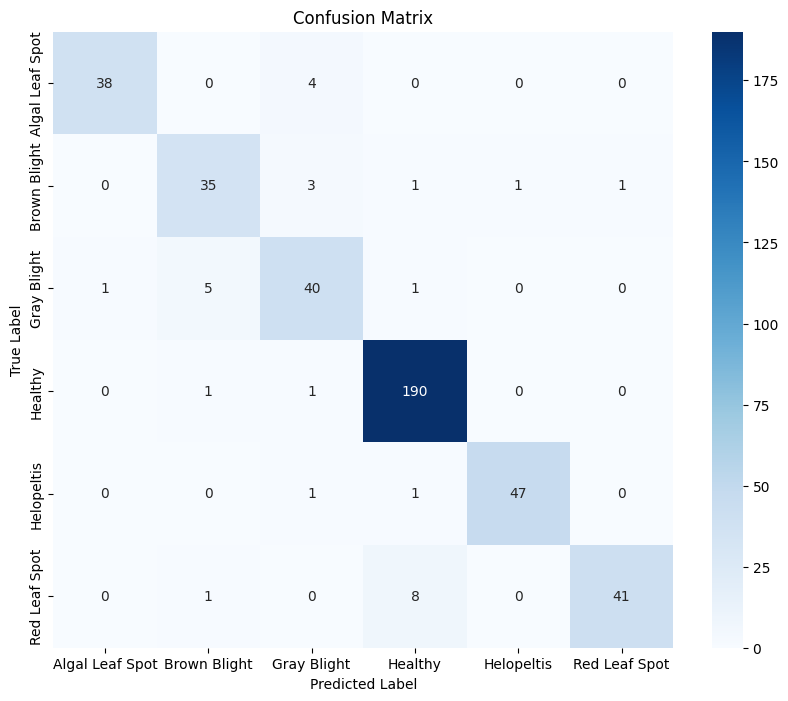

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [18]:
import os
import shutil
import torch

# Define the directory for collecting results
results_dir = 'Results'
os.makedirs(results_dir, exist_ok=True)

# 1. Save the best trained model weights
model_save_path = os.path.join(results_dir, 'best_model.pth')
torch.save(resnet50.state_dict(), model_save_path)
print(f"Best model weights saved to {model_save_path}")

# 2. Copy relevant informational files to the results directory
# Original output directory from extraction
output_dir = '/content/Tea_Leaf_Diseases'

files_to_copy = [
    'data.yaml',
    'README.dataset.txt',
    'README.roboflow.txt'
]

for filename in files_to_copy:
    source_path = os.path.join(output_dir, filename)
    destination_path = os.path.join(results_dir, filename)
    if os.path.exists(source_path):
        shutil.copy2(source_path, destination_path)
        print(f"Copied {filename} to {results_dir}/")
    else:
        print(f"Warning: {filename} not found at {source_path}")

print(f"All specified results and information collected in the '{results_dir}' directory.")

Best model weights saved to Results/best_model.pth
Copied data.yaml to Results/
Copied README.dataset.txt to Results/
Copied README.roboflow.txt to Results/
All specified results and information collected in the 'Results' directory.


In [19]:
# 3. Zip the Results directory
zip_filename = 'Results.zip'
shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', results_dir)
print(f"Successfully created {zip_filename}")

# Optional: Clean up the temporary results directory after zipping
# shutil.rmtree(results_dir)
# print(f"Cleaned up temporary '{results_dir}' directory.")

Successfully created Results.zip
